IMPORT LIBRARIES

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

DATASET LOADING

In [ ]:
# Load Dataset

files=["/content/sample_data/api_data_aadhar_biometric_0_500000.csv",
    "/content/sample_data/api_data_aadhar_biometric_500000_1000000.csv",
    "/content/sample_data/api_data_aadhar_biometric_1000000_1500000.csv",
    "/content/sample_data/api_data_aadhar_biometric_1500000_1861108.csv"]

biometric_df = pd.concat(
    (pd.read_csv(file, low_memory=False) for file in files),
    ignore_index=True
)


DATASET VIEW


In [ ]:
# Dataset First Look
biometric_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
biometric_df.shape

(1861108, 6)

### Dataset Information

In [ ]:
# Dataset Info
biometric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
biometric_df.duplicated().sum()


np.int64(94896)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
biometric_df.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0


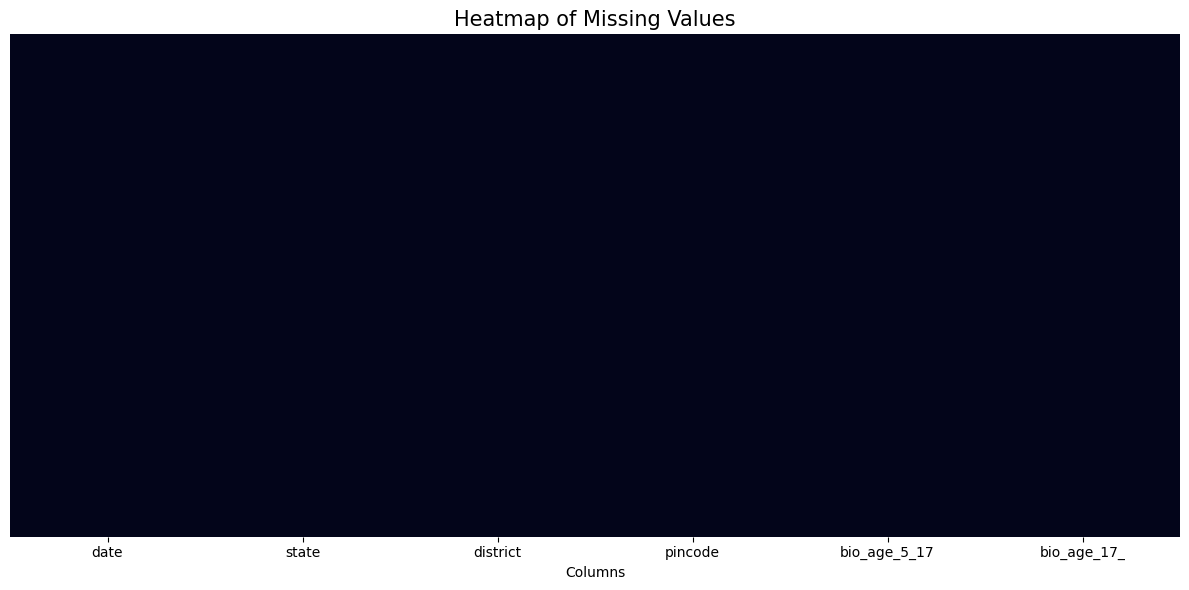

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))
sns.heatmap(biometric_df.isnull(),
            cmap='rocket',  # better color scheme
            cbar=False,
            yticklabels=False)  # hides row numbers for cleaner view
plt.title('Heatmap of Missing Values', fontsize=15)
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

In [ ]:
for col in biometric_df.select_dtypes(include=[np.number]).columns:
    print(col, np.isnan(biometric_df[col]).sum())


pincode 0
bio_age_5_17 0
bio_age_17_ 0


### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
biometric_df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [ ]:
# Dataset Describe
biometric_df.describe(include='all')

,date,state,district,pincode,bio_age_5_17,bio_age_17_
count,1861108,1861108,1861108,1.861108e+06,1.861108e+06,1.861108e+06
unique,89,57,974,NaN,NaN,NaN
top,25-12-2025,Tamil Nadu,Pune,NaN,NaN,NaN
freq,24646,184568,11586,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.217612e+05,1.839058e+01,1.909413e+01
std,NaN,NaN,NaN,1.981627e+05,8.370421e+01,8.806502e+01
min,NaN,NaN,NaN,1.100010e+05,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,3.911750e+05,1.000000e+00,1.000000e+00
50%,NaN,NaN,NaN,5.224010e+05,3.000000e+00,4.000000e+00
75%,NaN,NaN,NaN,6.866362e+05,1.100000e+01,1.000000e+01


In [ ]:
# Check Unique Values for each variable.
unique_values = pd.DataFrame({
    "Column": biometric_df.columns,
    "Unique_Values_Count": [biometric_df[col].nunique() for col in biometric_df.columns]
})

unique_values.sort_values(by="Unique_Values_Count", ascending=False)


,Column,Unique_Values_Count
3,pincode,19707
5,bio_age_17_,2212
4,bio_age_5_17,2121
2,district,974
0,date,89
1,state,57


from matplotlib import pyplot as plt
_df_0['Unique_Values_Count'].plot(kind='hist', bins=20, title='Unique_Values_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Column').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Unique_Values_Count'].plot(kind='line', figsize=(8, 4), title='Unique_Values_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['Column'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='Unique_Values_Count', y='Column', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# Display unique values for each column (use carefully for high-cardinality columns)
for col in biometric_df.columns:
    print(f"\n{col} ({biometric_df[col].nunique()} unique values):")
    print(biometric_df[col].unique())


date (89 unique values):
['01-03-2025' '01-04-2025' '01-05-2025' '01-06-2025' '01-07-2025'
 '01-09-2025' '02-09-2025' '03-09-2025' '04-09-2025' '05-09-2025'
 '06-09-2025' '07-09-2025' '08-09-2025' '09-09-2025' '10-09-2025'
 '11-09-2025' '12-09-2025' '13-09-2025' '14-09-2025' '15-09-2025'
 '16-09-2025' '17-09-2025' '18-09-2025' '19-09-2025' '20-09-2025'
 '13-10-2025' '15-10-2025' '16-10-2025' '17-10-2025' '18-10-2025'
 '19-10-2025' '20-10-2025' '21-10-2025' '22-10-2025' '23-10-2025'
 '24-10-2025' '25-10-2025' '26-10-2025' '27-10-2025' '28-10-2025'
 '29-10-2025' '30-10-2025' '31-10-2025' '01-11-2025' '02-11-2025'
 '03-11-2025' '04-11-2025' '05-11-2025' '06-11-2025' '07-11-2025'
 '08-11-2025' '09-11-2025' '10-11-2025' '11-11-2025' '12-11-2025'
 '13-11-2025' '14-11-2025' '15-11-2025' '16-11-2025' '17-11-2025'
 '18-11-2025' '19-11-2025' '25-11-2025' '01-12-2025' '02-12-2025'
 '03-12-2025' '04-12-2025' '05-12-2025' '06-12-2025' '07-12-2025'
 '08-12-2025' '09-12-2025' '10-12-2025' '11-12-202

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
# Write your code to make your dataset analysis ready.
# Creating a copy of the current dataset and assigning to d_clean
d_clean = biometric_df.copy()

In [ ]:
# Step 1: Ensure 'state' column is treated as string
# This prevents errors if there are numbers or NaN values
d_clean["state"] = d_clean["state"].astype(str)

# Step 2: Remove leading and trailing spaces
# Example: " West Bengal " → "West Bengal"
d_clean["state"] = d_clean["state"].str.strip()

# Step 3: Standardize text case using Title Case
# Examples:
# "WEST BENGAL"  → "West Bengal"
# "west bengal"  → "West Bengal"
# "West bengal"  → "West Bengal"
d_clean["state"] = d_clean["state"].str.title()


In [ ]:
# Step 1: Make sure 'state' column is string
# Safety step in case mixed data types exist
d_clean["state"] = d_clean["state"].astype(str)

# Step 2: Remove leading and trailing spaces
# Example: "  West Bengal  " → "West Bengal"
d_clean["state"] = d_clean["state"].str.strip()

# Step 3: Replace multiple spaces inside text with a single space
# Example: "West  Bengal" → "West Bengal"
d_clean["state"] = d_clean["state"].str.replace(r"\s+", " ", regex=True)


In [ ]:
# STEP 3: Fix spelling mistakes and old/alternate state names
# -----------------------------------------------------------
# Approach:
# 1) Normalize text (lowercase) to match mapping keys
# 2) Replace known wrong spellings / old names with official names
# 3) Convert back to Title Case for presentation

# 1) Normalize to lowercase for reliable matching
d_clean["state"] = d_clean["state"].str.lower()

# 2) Dictionary to fix spelling mistakes & legacy names
state_spelling_map = {
    # West Bengal variants
    "west bengal": "West Bengal",
    "westbengal": "West Bengal",
    "west bangal": "West Bengal",
    "west bengli": "West Bengal",

    # Odisha / Orissa
    "orissa": "Odisha",
    "odisha": "Odisha",
    "odisha ": "Odisha",

    # Puducherry / Pondicherry
    "pondicherry": "Puducherry",

    # Uttarakhand / Uttaranchal
    "uttaranchal": "Uttarakhand",

    # Jammu & Kashmir variants
    "jammu & kashmir": "Jammu and Kashmir",
    "jammu and kashmir": "Jammu and Kashmir",

    # Andhra Pradesh variants
    "andhra pradesh": "Andhra Pradesh",

    # Andaman & Nicobar Islands variants
    "andaman & nicobar islands": "Andaman and Nicobar Islands",
    "andaman and nicobar islands": "Andaman and Nicobar Islands",

    # Daman/Dadra variants
    "daman & diu": "Daman and Diu",
    "dadra & nagar haveli": "Dadra and Nagar Haveli",

    # Chhattisgarh misspelling
    "chhatisgarh": "Chhattisgarh"
}

# Apply mapping
d_clean["state"] = d_clean["state"].replace(state_spelling_map)

# 3) Final presentation format
d_clean["state"] = d_clean["state"].str.title()


In [ ]:
# STEP: Merge old UT names into the current official UT name
# Dadra and Nagar Haveli + Daman and Diu → single UT

d_clean["state"] = d_clean["state"].replace({
    "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu",
    "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu"
})


In [ ]:
valid_states = [
    # 28 States
    "Andhra Pradesh","Arunachal Pradesh","Assam","Bihar","Chhattisgarh",
    "Goa","Gujarat","Haryana","Himachal Pradesh","Jharkhand","Karnataka",
    "Kerala","Madhya Pradesh","Maharashtra","Manipur","Meghalaya","Mizoram",
    "Nagaland","Odisha","Punjab","Rajasthan","Sikkim","Tamil Nadu",
    "Telangana","Tripura","Uttar Pradesh","Uttarakhand","West Bengal",

    # 8 Union Territories
    "Andaman And Nicobar Islands","Chandigarh",
    "Dadra And Nagar Haveli And Daman And Diu",
    "Delhi","Jammu And Kashmir","Ladakh",
    "Lakshadweep","Puducherry"
]


In [ ]:
# Create a flag column to identify invalid states
d_clean["invalid_state_flag"] = ~d_clean["state"].isin(valid_states)


In [ ]:
d_clean["invalid_state_flag"].value_counts()


,count
invalid_state_flag,
False,1861107
True,1


In [ ]:
# Identify and count invalid (non-state) values in the 'state' column to review data quality issues before cleaning
d_clean.loc[d_clean["invalid_state_flag"], "state"].value_counts()


,count
state,
Tamilnadu,1


In [ ]:
# Keep only rows where the 'state' value is a valid Indian State or Union Territory, removing all non-state entries
d_clean = d_clean[d_clean["state"].isin(valid_states)].copy()


In [ ]:
for col in d_clean.columns:
    print(f"\n{col} ({d_clean[col].nunique()} unique values):")
    print(d_clean[col].unique())


date (89 unique values):
['01-03-2025' '01-04-2025' '01-05-2025' '01-06-2025' '01-07-2025'
 '01-09-2025' '02-09-2025' '03-09-2025' '04-09-2025' '05-09-2025'
 '06-09-2025' '07-09-2025' '08-09-2025' '09-09-2025' '10-09-2025'
 '11-09-2025' '12-09-2025' '13-09-2025' '14-09-2025' '15-09-2025'
 '16-09-2025' '17-09-2025' '18-09-2025' '19-09-2025' '20-09-2025'
 '13-10-2025' '15-10-2025' '16-10-2025' '17-10-2025' '18-10-2025'
 '19-10-2025' '20-10-2025' '21-10-2025' '22-10-2025' '23-10-2025'
 '24-10-2025' '25-10-2025' '26-10-2025' '27-10-2025' '28-10-2025'
 '29-10-2025' '30-10-2025' '31-10-2025' '01-11-2025' '02-11-2025'
 '03-11-2025' '04-11-2025' '05-11-2025' '06-11-2025' '07-11-2025'
 '08-11-2025' '09-11-2025' '10-11-2025' '11-11-2025' '12-11-2025'
 '13-11-2025' '14-11-2025' '15-11-2025' '16-11-2025' '17-11-2025'
 '18-11-2025' '19-11-2025' '25-11-2025' '01-12-2025' '02-12-2025'
 '03-12-2025' '04-12-2025' '05-12-2025' '06-12-2025' '07-12-2025'
 '08-12-2025' '09-12-2025' '10-12-2025' '11-12-202

In [ ]:
# Drop the helper column 'invalid_state_flag' as it is no longer needed after cleaning the state values
d_clean.drop(columns=["invalid_state_flag"], inplace=True)


In [ ]:
d_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1861107 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 99.4+ MB


In [ ]:
# STEP 1: Fix case inconsistency in the 'district' column
# -------------------------------------------------------
# This ensures that the same district written in different cases
# (e.g., "HOWRAH", "hooghly", "Kolkata") is standardized to one format
# so that grouping and aggregation work correctly.

d_clean["district"] = (
    d_clean["district"]
    .astype(str)      # Convert to string to safely handle NaN or numeric values
    .str.strip()      # Remove leading and trailing spaces
    .str.title()      # Convert to Title Case (e.g., "HOWRAH" → "Howrah")
)


In [ ]:
# STEP 2: Remove extra spaces and special / hidden characters from the 'district' column
# -------------------------------------------------------------------------------------
# This fixes issues like:
# "South  24 Parganas" → "South 24 Parganas"
# "Deeg " → "Deeg"
# Unicode dash or non-breaking spaces that break grouping

d_clean["district"] = (
    d_clean["district"]
    .astype(str)                                   # Ensure string type
    .str.replace(r"\s+", " ", regex=True)          # Replace multiple spaces with a single space
    .str.replace(r"[^\x00-\x7F]+", "", regex=True) # Remove non-ASCII / hidden unicode characters
    .str.strip()                                   # Trim leading and trailing spaces
)


In [ ]:
# STEP 3: Fix common spelling variations in the 'district' column
# ---------------------------------------------------------------
# This standardizes districts that appear with different spellings
# so they are treated as a single entity during analysis.
# Example:
# "Hooghiy", "Hugli", "Hooghly" → "Hooghly"
# "West Midnapore", "West Medinipur" → "West Medinipur"

# Normalize to lowercase for reliable matching
d_clean["district"] = d_clean["district"].str.lower()

# Dictionary of common district spelling variants → standard name
district_spelling_map = {
    # West Bengal
    "hooghiy": "Hooghly",
    "hugli": "Hooghly",
    "hooghly": "Hooghly",
    "haora": "Howrah",
    "howrah": "Howrah",
    "kolkata": "Kolkata",
    "barddhaman": "Bardhaman",
    "bardhaman": "Bardhaman",
    "west midnapore": "West Medinipur",
    "west medinipur": "West Medinipur",
    "east midnapore": "Purba Medinipur",
    "east midnapur": "Purba Medinipur",
    "purba medinipur": "Purba Medinipur",

    # Tamil Nadu
    "tuticorin": "Thoothukkudi",
    "thoothukudi": "Thoothukkudi",

    # Karnataka
    "bangalore": "Bengaluru",
    "bangalore rural": "Bengaluru Rural",
    "bellary": "Ballari",
    "chickmagalur": "Chikkamagaluru",
    "chikmagalur": "Chikkamagaluru",

    # Andhra Pradesh / Telangana
    "anantapur": "Anantapur",
    "anantapuramu": "Anantapur",
    "kadapa": "Cuddapah",
    "cuddapah": "Cuddapah"
}

# Apply spelling corrections
d_clean["district"] = d_clean["district"].replace(district_spelling_map)

# Convert back to Title Case for presentation
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP 4: Standardize OLD vs NEW district names
# ---------------------------------------------
# Many districts were renamed over time. This step maps old names
# to their current official names so that historical and recent data
# align correctly in analysis.
# Example:
# "Allahabad" → "Prayagraj"
# "Faizabad" → "Ayodhya"
# "Ahmed Nagar" → "Ahilyanagar"
# "Aurangabad" → "Chhatrapati Sambhajinagar"

# Normalize to lowercase for consistent matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of old district names to new official names
old_to_new_district_map = {
    # Uttar Pradesh
    "allahabad": "Prayagraj",
    "faizabad": "Ayodhya",

    # Maharashtra
    "ahmed nagar": "Ahilyanagar",
    "ahmadnagar": "Ahilyanagar",
    "aurangabad": "Chhatrapati Sambhajinagar",

    # Tamil Nadu
    "ramanathapuram": "Ramanathapuram",  # (example kept same for clarity)

    # Andhra Pradesh / Telangana (recent reorganizations)
    "warangal urban": "Hanumakonda",
    "warangal rural": "Warangal",

    # Jammu & Kashmir
    "badgam": "Budgam"
}

# Apply old → new district name mapping
d_clean["district"] = d_clean["district"].replace(old_to_new_district_map)

# Convert back to Title Case for clean presentation
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP 5: Clean district names by removing extra text, symbols, and annotations
# -----------------------------------------------------------------------------
# This handles cases like:
# "Gadag *" → "Gadag"
# "Dist : Thane" → "Thane"
# "Bijapur(KAR)" → "Bijapur"
# "Aurangabad(BH)" → "Aurangabad"
# "Mumbai( Sub Urban )" → "Mumbai Sub Urban"

import re

d_clean["district"] = (
    d_clean["district"]
    .astype(str)  # Ensure string type
    # Remove common prefixes like "Dist :" or similar
    .str.replace(r"^dist\s*:\s*", "", regex=True)
    # Remove text inside parentheses (state codes, notes)
    .str.replace(r"\([^)]*\)", "", regex=True)
    # Remove trailing asterisks or special symbols
    .str.replace(r"[*]+$", "", regex=True)
    # Replace multiple spaces with a single space
    .str.replace(r"\s+", " ", regex=True)
    # Trim leading/trailing spaces
    .str.strip()
    # Standardize case for consistency
    .str.title()
)


In [ ]:
# STEP 6: Handle city / sub-district / locality values mixed into 'district'
# -------------------------------------------------------------------------
# Problem examples:
# "New Delhi", "Najafgarh", "South DumDum(M)", "Domjur", "Bally Jagachha"
#
# Strategy:
# 1) Identify known city / locality names that are NOT districts
# 2) Replace them with the correct district name (preferred)
# 3) If mapping is not possible, mark them as NaN for later review

# Normalize for matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of city/locality → correct district
city_to_district_map = {
    # Delhi
    "new delhi": "Central Delhi",
    "najafgarh": "South West Delhi",
    "north east": "North East Delhi",
    "south east delhi": "South East Delhi",

    # West Bengal
    "south dumdum": "North 24 Parganas",
    "bally jagachha": "Howrah",
    "domjur": "Howrah",

    # Maharashtra
    "mumbai city": "Mumbai",
    "mumbai suburban": "Mumbai",
    "mumbai( sub urban )": "Mumbai",

    # Karnataka
    "bangalore": "Bengaluru",
    "bangalore rural": "Bengaluru Rural",

    # Tamil Nadu
    "tuticorin": "Thoothukkudi"
}

# Apply mapping
d_clean["district"] = d_clean["district"].replace(city_to_district_map)

# Convert back to title case
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP 7: Handle district split / merge variants
# ----------------------------------------------
# Problem:
# Some districts appear in multiple administrative forms due to splits or mergers.
# If left as-is, they cause double counting or fragmented analysis.
#
# Strategy (Hackathon-friendly & safe):
# - Merge related variants into ONE standard district name
# - Keep analysis consistent at district level
#
# Examples:
# "Mumbai City", "Mumbai Suburban", "Mumbai( Sub Urban )" → "Mumbai"
# "Bangalore", "Bengaluru", "Bengaluru South" → "Bengaluru"
# "Aurangabad", "Chhatrapati Sambhajinagar" → "Chhatrapati Sambhajinagar"

# Normalize for matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of split / merged districts → single standard district
district_merge_map = {
    # Maharashtra
    "mumbai city": "Mumbai",
    "mumbai suburban": "Mumbai",
    "mumbai sub urban": "Mumbai",
    "mumbai( sub urban )": "Mumbai",

    "aurangabad": "Chhatrapati Sambhajinagar",
    "chatrapati sambhaji nagar": "Chhatrapati Sambhajinagar",

    # Karnataka
    "bangalore": "Bengaluru",
    "bengaluru south": "Bengaluru",
    "bangalore rural": "Bengaluru Rural",

    # Andhra Pradesh / Telangana
    "warangal urban": "Hanumakonda",
    "warangal rural": "Warangal",

    # Tamil Nadu
    "chennai": "Chennai",   # kept explicit for clarity
    "chengalpattu": "Chengalpattu"
}

# Apply merge rules
d_clean["district"] = d_clean["district"].replace(district_merge_map)

# Convert back to Title Case for reporting
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP 8: Handle completely invalid / directional district values
# ---------------------------------------------------------------
# Problem examples:
# "East", "West", "North", "South", "North East", "South West", etc.
# These are NOT districts and should not participate in aggregation.
#
# Strategy:
# 1) Define a list of invalid / directional-only values
# 2) Flag them for transparency
# 3) Remove them from the dataset (recommended for hackathon analysis)

# Normalize for reliable matching
d_clean["district"] = d_clean["district"].astype(str).str.strip()

# List of invalid / directional-only values
invalid_district_values = [
    "East", "West", "North", "South",
    "North East", "North West", "South East", "South West"
]

# Create a helper flag to identify invalid districts
d_clean["invalid_district_flag"] = d_clean["district"].isin(invalid_district_values)

# Inspect invalid values before removal (optional but good practice)
print(d_clean.loc[d_clean["invalid_district_flag"], "district"].value_counts())

# Remove invalid / directional district rows
d_clean = d_clean[~d_clean["invalid_district_flag"]].copy()

# Drop helper flag column after cleaning
d_clean.drop(columns=["invalid_district_flag"], inplace=True)


district
East     587
South    337
West     194
North    104
Name: count, dtype: int64


In [ ]:
# STEP 9: Fix encoding / Unicode issues in the 'district' column
# --------------------------------------------------------------
# Problem:
# Some district names contain hidden or broken Unicode characters
# due to encoding issues (e.g., "Medchalâˆ’Malkajgiri", strange dashes).
#
# Goal:
# Convert such values into clean, readable ASCII text so that
# grouping and matching work correctly.

import unicodedata

d_clean["district"] = (
    d_clean["district"]
    .astype(str)  # Ensure string type
    # Normalize Unicode characters (e.g., fancy dashes → standard dash)
    .apply(lambda x: unicodedata.normalize("NFKD", x))
    # Remove any remaining non-ASCII characters
    .str.encode("ascii", "ignore")
    .str.decode("ascii")
    # Replace multiple spaces created after cleanup
    .str.replace(r"\s+", " ", regex=True)
    # Trim leading/trailing spaces
    .str.strip()
)


In [ ]:
# Check districts that appear in more than one state
district_state_counts = (
    d_clean.groupby("district")["state"]
    .nunique()
    .sort_values(ascending=False)
)

# Show districts present in multiple states
district_state_counts[district_state_counts > 1].head(20)


,state
district,
Hamirpur,2
Kargil,2
Balrampur,2
Medak,2
Karimnagar,2
Chhatrapati Sambhajinagar,2
Khammam,2
Pratapgarh,2
Hyderabad,2


In [ ]:
# STEP A: Fix remaining obvious spelling variants in 'district'
# -------------------------------------------------------------
# Purpose:
# Some districts still appear with minor spelling / format differences.
# We map them to ONE standard, officially used district name.
# This avoids duplicate districts in final aggregation.

# Normalize to lowercase for reliable matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of remaining spelling variants → standard district name
district_spelling_fix = {
    # Telangana
    "medchalmalkajgiri": "Medchal-Malkajgiri",
    "medchal?malkajgiri": "Medchal-Malkajgiri",
    "medchal-malkajgiri": "Medchal-Malkajgiri",

    "karim nagar": "Karimnagar",
    "mahabub nagar": "Mahabubnagar",

    # Chhattisgarh
    "janjgir champa": "Janjgir-Champa",
    "janjgir - champa": "Janjgir-Champa",

    # Himachal Pradesh
    "lahul and spiti": "Lahaul And Spiti",
    "lahul & spiti": "Lahaul And Spiti",
    "lahaul and spiti": "Lahaul And Spiti",

    # Uttar Pradesh
    "raebareli": "Rae Bareli",

    # Andhra Pradesh
    "anugal": "Anugul"   # common typo observed
}

# Apply spelling corrections
d_clean["district"] = d_clean["district"].replace(district_spelling_fix)

# Convert back to Title Case for reporting
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP B: Align OLD district names with NEW official names
# -------------------------------------------------------
# Purpose:
# Some districts were renamed over time. This step ensures that
# historical and recent data use ONE official district name,
# so trends and aggregations remain consistent.

# Normalize to lowercase for reliable matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of old district names → current official names
old_to_new_district_map = {
    # Uttar Pradesh
    "allahabad": "Prayagraj",
    "faizabad": "Ayodhya",
    "raebareli": "Rae Bareli",

    # Maharashtra
    "ahmed nagar": "Ahilyanagar",
    "ahmadnagar": "Ahilyanagar",
    "aurangabad": "Chhatrapati Sambhajinagar",

    # Telangana
    "karim nagar": "Karimnagar",
    "mahabub nagar": "Mahabubnagar",
    "rangareddi": "Rangareddy",

    # Jammu & Kashmir
    "badgam": "Budgam",

    # Odisha
    "anugul": "Angul",
    "baudh": "Boudh"
}

# Apply old → new name mapping
d_clean["district"] = d_clean["district"].replace(old_to_new_district_map)

# Convert back to Title Case for clean presentation
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP A (FINAL): Merge remaining districts that still appear in multiple forms
# ----------------------------------------------------------------------------
# Purpose:
# A few districts still exist with minor format / wording differences.
# This step consolidates them into ONE standard district name to prevent
# duplicate districts during aggregation.
#
# Examples handled here:
# "K.V. Rangareddy", "K.V.Rangareddy", "Rangareddy" → "Rangareddy"
# "South 24 Pargana" → "South 24 Parganas"
# "North Twenty Four Parganas" → "North 24 Parganas"
# "Medinipur" → "West Medinipur" (policy decision)

# Normalize to lowercase for reliable matching
d_clean["district"] = d_clean["district"].str.lower()

# Mapping of remaining multi-form districts → single standard name
final_multi_form_map = {
    "k.v. rangareddy": "Rangareddy",
    "k.v.rangareddy": "Rangareddy",
    "rangareddy": "Rangareddy",

    "south 24 pargana": "South 24 Parganas",
    "south 24 parganas": "South 24 Parganas",

    "north twenty four parganas": "North 24 Parganas",
    "north 24 parganas": "North 24 Parganas",

    "medinipur": "West Medinipur"
}

# Apply final consolidation mapping
d_clean["district"] = d_clean["district"].replace(final_multi_form_map)

# Convert back to Title Case for reporting consistency
d_clean["district"] = d_clean["district"].str.title()


In [ ]:
# STEP B (FINAL): Remove leftover prefixes / suffixes from district names
# ---------------------------------------------------------------------
# Purpose:
# Some district names still contain unwanted prefixes or suffixes
# that were not fully cleaned earlier.
#
# Examples handled:
# "Dist : Thane"        → "Thane"
# "Tamulpur District"   → "Tamulpur"
# Extra words like "District", ":" etc. should not be part of district name.

# Ensure district column is string
d_clean["district"] = d_clean["district"].astype(str)

# Remove common prefixes like "Dist :" (case-insensitive)
d_clean["district"] = d_clean["district"].str.replace(
    r"^dist\s*:\s*", "", regex=True, case=False
)

# Remove suffix word "District" if present at the end
d_clean["district"] = d_clean["district"].str.replace(
    r"\s+district$", "", regex=True, case=False
)

# Clean up extra spaces introduced after replacements
d_clean["district"] = (
    d_clean["district"]
    .str.replace(r"\s+", " ", regex=True)  # multiple spaces → single
    .str.strip()                           # trim leading/trailing spaces
    .str.title()                           # standard title case
)


In [ ]:
for col in d_clean.columns:
    print(f"\n{col} ({d_clean[col].nunique()} unique values):")
    print(d_clean[col].unique())


date (89 unique values):
['01-03-2025' '01-04-2025' '01-05-2025' '01-06-2025' '01-07-2025'
 '01-09-2025' '02-09-2025' '03-09-2025' '04-09-2025' '05-09-2025'
 '06-09-2025' '07-09-2025' '08-09-2025' '09-09-2025' '10-09-2025'
 '11-09-2025' '12-09-2025' '13-09-2025' '14-09-2025' '15-09-2025'
 '16-09-2025' '17-09-2025' '18-09-2025' '19-09-2025' '20-09-2025'
 '13-10-2025' '15-10-2025' '16-10-2025' '17-10-2025' '18-10-2025'
 '19-10-2025' '20-10-2025' '21-10-2025' '22-10-2025' '23-10-2025'
 '24-10-2025' '25-10-2025' '26-10-2025' '27-10-2025' '28-10-2025'
 '29-10-2025' '30-10-2025' '31-10-2025' '01-11-2025' '02-11-2025'
 '03-11-2025' '04-11-2025' '05-11-2025' '06-11-2025' '07-11-2025'
 '08-11-2025' '09-11-2025' '10-11-2025' '11-11-2025' '12-11-2025'
 '13-11-2025' '14-11-2025' '15-11-2025' '16-11-2025' '17-11-2025'
 '18-11-2025' '19-11-2025' '25-11-2025' '01-12-2025' '02-12-2025'
 '03-12-2025' '04-12-2025' '05-12-2025' '06-12-2025' '07-12-2025'
 '08-12-2025' '09-12-2025' '10-12-2025' '11-12-202

In [ ]:
state_ut_districts = {
    state: sorted(
        d_clean.loc[d_clean["state"] == state, "district"].unique().tolist()
    )
    for state in valid_states
}


In [ ]:
state_ut_districts["Uttar Pradesh"]


['Agra',
 'Aligarh',
 'Ambedkar Nagar',
 'Amethi',
 'Amroha',
 'Auraiya',
 'Ayodhya',
 'Azamgarh',
 'Baghpat',
 'Bagpat',
 'Bahraich',
 'Ballia',
 'Balrampur',
 'Banda',
 'Bara Banki',
 'Barabanki',
 'Bareilly',
 'Basti',
 'Bhadohi',
 'Bijnor',
 'Budaun',
 'Bulandshahar',
 'Bulandshahr',
 'Chandauli',
 'Chitrakoot',
 'Deoria',
 'Etah',
 'Etawah',
 'Farrukhabad',
 'Fatehpur',
 'Firozabad',
 'Gautam Buddha Nagar',
 'Ghaziabad',
 'Ghazipur',
 'Gonda',
 'Gorakhpur',
 'Hamirpur',
 'Hapur',
 'Hardoi',
 'Hathras',
 'Jalaun',
 'Jaunpur',
 'Jhansi',
 'Jyotiba Phule Nagar',
 'Kannauj',
 'Kanpur Dehat',
 'Kanpur Nagar',
 'Kasganj',
 'Kaushambi',
 'Kheri',
 'Kushinagar',
 'Lalitpur',
 'Lucknow',
 'Maharajganj',
 'Mahoba',
 'Mahrajganj',
 'Mainpuri',
 'Mathura',
 'Mau',
 'Meerut',
 'Mirzapur',
 'Moradabad',
 'Muzaffarnagar',
 'Pilibhit',
 'Pratapgarh',
 'Prayagraj',
 'Rae Bareli',
 'Rampur',
 'Saharanpur',
 'Sambhal',
 'Sant Kabir Nagar',
 'Sant Ravidas Nagar',
 'Sant Ravidas Nagar Bhadohi',
 'Shah

In [ ]:
d_clean.duplicated().sum()

np.int64(96667)

In [ ]:
 # Convert 'date' column from object to datetime (DD-MM-YYYY format)
d_clean["date"] = pd.to_datetime(
    d_clean["date"],
    format="%d-%m-%Y",
    errors="coerce"
)


In [ ]:
# Check datatype
print(d_clean["date"].dtype)

# Check if any invalid dates exist
d_clean[d_clean["date"].isna()]


datetime64[ns]


,date,state,district,pincode,bio_age_5_17,bio_age_17_


In [ ]:
d_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1859885 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       int64         
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 99.3+ MB


In [ ]:
# Extract Year from date
d_clean["year"] = d_clean["date"].dt.year

# Extract Month name (January, February, etc.)
d_clean["month_name"] = d_clean["date"].dt.month_name()

In [ ]:
d_clean[["date", "year", "month_name"]].head()


,date,year,month_name
0,2025-03-01,2025,March
1,2025-03-01,2025,March
2,2025-03-01,2025,March
3,2025-03-01,2025,March
4,2025-03-01,2025,March


In [ ]:
# Save cleaned dataset as CSV
d_clean.to_csv("aadhaar_clean_dataset.csv", index=False)


In [ ]:
for col in d_clean.columns:
    print(f"\n{col} ({d_clean[col].nunique()} unique values):")
    print(d_clean[col].unique())


date (89 unique values):
<DatetimeArray>
['2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-09-01 00:00:00',
 '2025-09-02 00:00:00', '2025-09-03 00:00:00', '2025-09-04 00:00:00',
 '2025-09-05 00:00:00', '2025-09-06 00:00:00', '2025-09-07 00:00:00',
 '2025-09-08 00:00:00', '2025-09-09 00:00:00', '2025-09-10 00:00:00',
 '2025-09-11 00:00:00', '2025-09-12 00:00:00', '2025-09-13 00:00:00',
 '2025-09-14 00:00:00', '2025-09-15 00:00:00', '2025-09-16 00:00:00',
 '2025-09-17 00:00:00', '2025-09-18 00:00:00', '2025-09-19 00:00:00',
 '2025-09-20 00:00:00', '2025-10-13 00:00:00', '2025-10-15 00:00:00',
 '2025-10-16 00:00:00', '2025-10-17 00:00:00', '2025-10-18 00:00:00',
 '2025-10-19 00:00:00', '2025-10-20 00:00:00', '2025-10-21 00:00:00',
 '2025-10-22 00:00:00', '2025-10-23 00:00:00', '2025-10-24 00:00:00',
 '2025-10-25 00:00:00', '2025-10-26 00:00:00', '2025-10-27 00:00:00',
 '2025-10-28 00:00:00', '2025-10-29 00:00:00', '

In [ ]:
from google.colab import files

d_clean.to_csv("aadhaar_clean_dataset.csv", index=False)
files.download("aadhaar_clean_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>